In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target 

print("Dataset Shape:", df.shape)
print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Data Information ---")
display(df.info())

print("\n--- Missing Values Check ---")
print(df.isnull().sum().sum(), "Missing Values")

Dataset Shape: (569, 31)

--- First 5 rows ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  

None


--- Missing Values Check ---
0 Missing Values


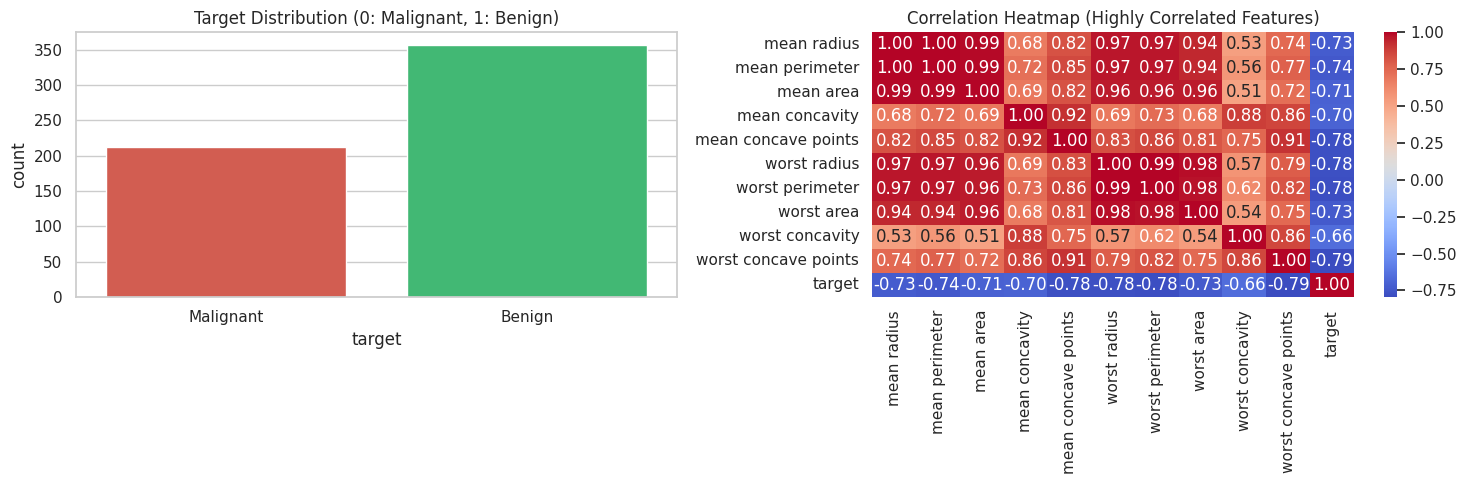

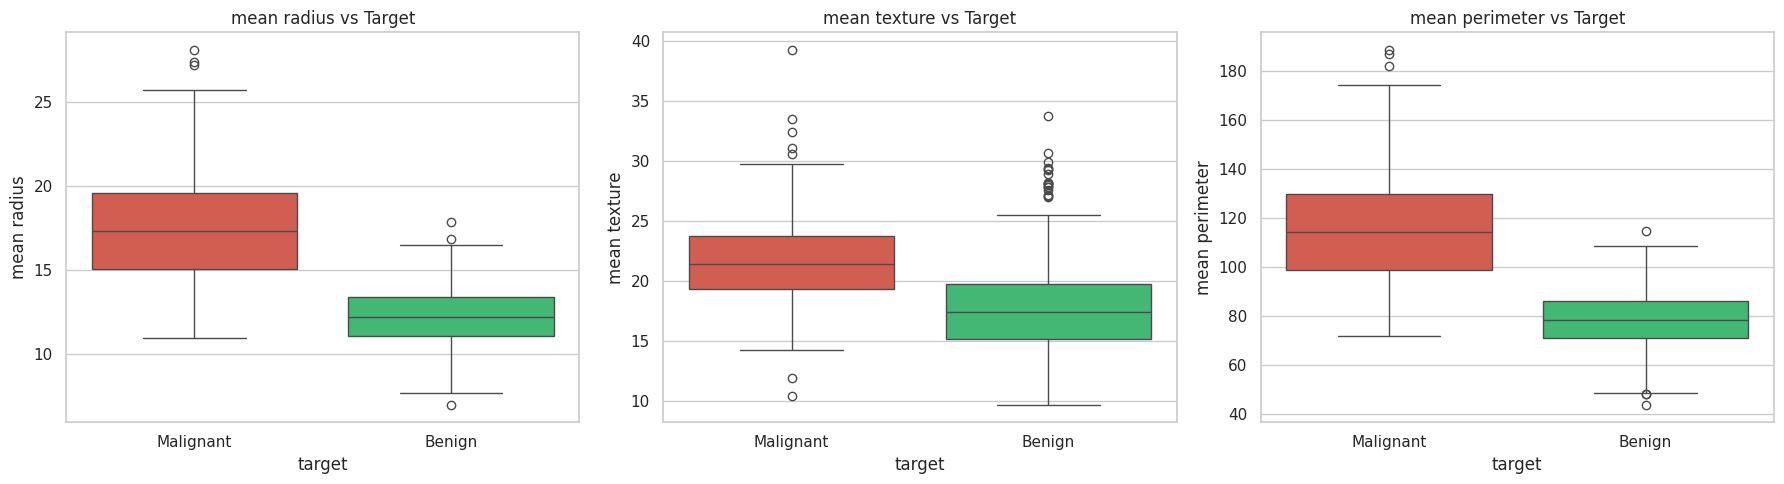

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.countplot(x='target', data=df, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Target Distribution (0: Malignant, 1: Benign)')
axes[0].set_xticklabels(['Malignant', 'Benign'])


corr = df.corr()
top_features = corr.index[abs(corr['target']) > 0.6] 
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlation Heatmap (Highly Correlated Features)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter']

for i, feature in enumerate(features_to_plot):
    sns.boxplot(x='target', y=feature, data=df, ax=axes[i], palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'{feature} vs Target')
    axes[i].set_xticklabels(['Malignant', 'Benign'])
    
plt.tight_layout()
plt.show()

In [4]:

X = df.drop('target', axis=1)
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [5]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42, probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# قاموس لحفظ النتائج
results = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    
    y_pred = model.predict(X_test_scaled)
    
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = [acc, prec, rec, f1]
    
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")


results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
display(results_df)

--- Logistic Regression ---
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

--- SVM ---
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

--- Random Forest ---
Accuracy:  0.9561
Precision: 0.9589
Recall:    0.9722
F1-Score:  0.9655

--- XGBoost ---
Accuracy:  0.9561
Precision: 0.9467
Recall:    0.9861
F1-Score:  0.9660



,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.982456,0.986111,0.986111,0.986111
SVM,0.982456,0.986111,0.986111,0.986111
Random Forest,0.956140,0.958904,0.972222,0.965517
XGBoost,0.956140,0.946667,0.986111,0.965986


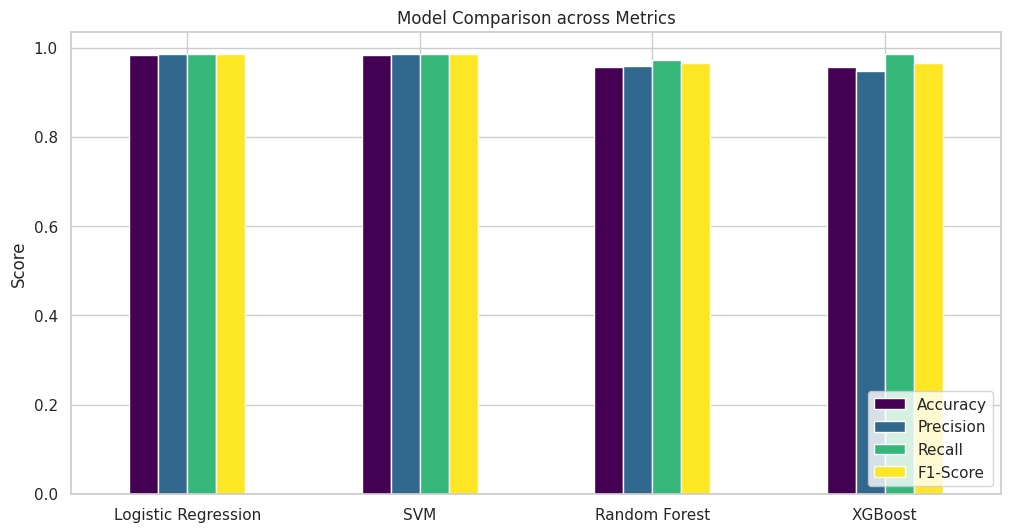

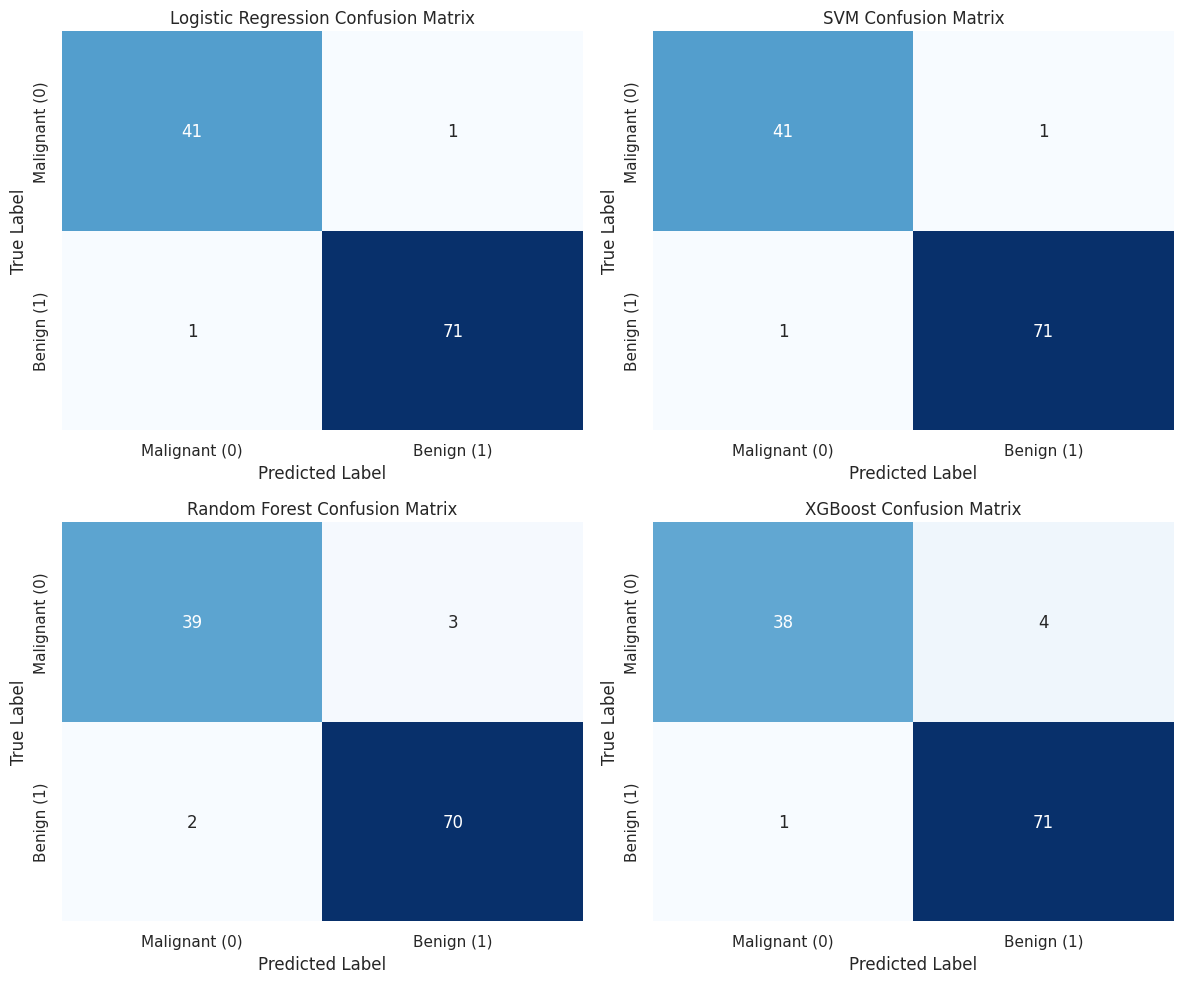

In [6]:

results_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Comparison across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].set_xticklabels(['Malignant (0)', 'Benign (1)'])
    axes[i].set_yticklabels(['Malignant (0)', 'Benign (1)'])

plt.tight_layout()
plt.show()